# 08 — `clim_short`-only out-of-domain ablation

**Experimental only.** `src/inference.py`, `models/`, the API, the dashboard and notebooks 01–07 are
untouched. Nothing is deployed.

## Pre-specified hypothesis

Stated before any result in this notebook was seen, and carried unchanged from the notebook 07
recommendation:

> **`clim_short` transfers better than `acc_w4`.** A 17-feature model (16 + `clim_short`) should keep
> the transferable persistent-fault gains and drop the transferable spike/noise losses that the
> 18-feature dual model showed out of domain.

This notebook is a **confirmation run**, not a search. The protocol is notebook 07's, unchanged, with
new fault seeds. No feature is added, no threshold is touched, nothing is tuned.

## Conditions

| | features | role |
|---|---|---|
| **A** `baseline16` | the existing 16 | control |
| **B** `clim_short17` | 16 + `clim_short` | **the candidate** |
| *(ref)* `dual18` | 16 + `clim_short` + `acc_w4` | reference only |

**Why `dual18` appears here at all.** The brief says not to include `acc_w4` in the candidate model,
and it is not in condition B. But decision criterion C asks whether B's generalization gap is smaller
than the 18-feature dual's, and that cannot be answered honestly by comparing against notebook 07's
numbers — those used different fault seeds. `dual18` is therefore re-run on **matched seeds** purely
as a reference line. It is not a candidate and no recommendation will be made for it.

## Fault seeds

Notebook 07 used 71/82/93. This notebook uses **104/115/126** — independent of every seed used
anywhere previously, for feature selection or evaluation.

In [1]:
import sys, os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from fault_injection import FaultSimulator, CHALLENGE_CONFIG, VARS
from inference import WeatherFaultDetector
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.width", 215); pd.set_option("display.max_columns", 60)

NOMINAL, ROLL, ROLLMIN = 3.0, "24h", 4
SEEDS = [104, 115, 126]                    # new; notebook 07 used 71/82/93
TRANSIENT = ["spike", "intermittent_spikes"]

MAN = pd.read_csv("../data/processed/stations/station_manifest.csv", dtype={"station_id": str})
STATIONS = (MAN.drop_duplicates("station_id")
            .set_index("station_id")[["name", "lat", "lon", "elevation_m", "environment"]])
print(STATIONS.to_string())

def load(sid, year):
    d = pd.read_csv(f"../data/processed/stations/{sid}_{year}.csv", parse_dates=["time"])
    return d[["time"] + VARS].reset_index(drop=True)

                           name    lat    lon  elevation_m              environment
station_id                                                                         
42182099999  Safdarjung (Delhi)  28.58  77.21          215      inland N, semi-arid
42101099999             Patiala  30.33  76.47          251  inland N, Punjab plains
42410099999            Guwahati  26.11  91.59           49             NE, very wet
42647099999           Ahmedabad  23.08  72.63           58                   arid W
42809099999             Kolkata  22.65  88.45            5           E delta, humid
43003099999              Mumbai  19.09  72.87           11                W coastal
43279099999             Chennai  12.99  80.18           16               SE coastal
43371099999  Thiruvananthapuram   8.48  76.95           64   far S coastal tropical


## 1. Pipeline — identical to notebook 07, re-verified against production

In [2]:
def _steps(out):
    out["gap_hours"] = out.time.diff().dt.total_seconds() / 3600.0
    ok = out.gap_hours.eq(NOMINAL)
    for v in VARS:
        out[f"{v}_step"] = out[v].diff().where(ok)
    return out

def _rolling(out):
    s = out.set_index("time")
    for v in VARS:
        r = s[v].rolling(ROLL, center=True, min_periods=ROLLMIN)
        med = r.median().to_numpy(); sd = r.std().to_numpy()
        med = np.where(np.isnan(med), out[v].to_numpy(), med)
        out[f"{v}_roll_med"], out[f"{v}_roll_std"] = med, sd
        out[f"{v}_resid"] = out[v].to_numpy() - med
    return out

def fit_climatology(frame, half=7, min_periods=3):
    clim = {}
    t = frame.copy(); t["date"] = t.time.dt.normalize(); t["hour"] = t.time.dt.hour.astype("int64")
    days = pd.date_range(t.date.min(), t.date.max(), freq="D"); w = 2 * half + 1
    for v in VARS:
        wide = t.pivot_table(index="date", columns="hour", values=v, aggfunc="mean").reindex(days)
        pad = pd.concat([wide.iloc[-half:], wide, wide.iloc[:half]], axis=0)
        r = pad.rolling(w, center=True, min_periods=min_periods)
        m = r.mean().iloc[half:len(pad) - half]; s = r.std().iloc[half:len(pad) - half]
        m.index, s.index = wide.index, wide.index
        floor = 0.10 * float(frame[v].std())
        mu, sd = m.stack(), s.stack().clip(lower=floor)
        idx = pd.MultiIndex.from_arrays([mu.index.get_level_values(0).dayofyear,
                                         mu.index.get_level_values(1).astype("int64")],
                                        names=["doy", "hour"])
        mu.index = idx; sd.index = idx
        clim[v] = {"mean": mu[~mu.index.duplicated()], "std": sd[~sd.index.duplicated()]}
    return clim

def fit_roll_fill(frame):
    f = _rolling(_steps(frame.copy()))
    return {f"{v}_roll_std": float(f[f"{v}_roll_std"].median()) for v in VARS}

FEATS16 = ["temp_c_step", "slp_hpa_step", "rh_pct_step",
           "temp_c_roll_std", "slp_hpa_roll_std", "rh_pct_roll_std",
           "temp_c_resid", "slp_hpa_resid", "rh_pct_resid",
           "temp_c_clim_dev", "slp_hpa_clim_dev", "rh_pct_clim_dev",
           "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
CD = [f"{v}_clim_dev" for v in VARS]

def build_features(frame, clim, fill):
    out = _steps(frame.copy())
    hour = out.time.dt.hour.to_numpy(); doy = out.time.dt.dayofyear.to_numpy()
    out["hour_sin"] = np.sin(2*np.pi*hour/24);   out["hour_cos"] = np.cos(2*np.pi*hour/24)
    out["doy_sin"]  = np.sin(2*np.pi*doy/365.25); out["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    out = _rolling(out)
    key = pd.MultiIndex.from_arrays([out.time.dt.dayofyear.astype("int64"),
                                     out.time.dt.hour.astype("int64")], names=["doy", "hour"])
    for v in VARS:
        mu = clim[v]["mean"].reindex(key).to_numpy(); sd = clim[v]["std"].reindex(key).to_numpy()
        out[f"{v}_clim_dev"] = (out[v].to_numpy() - mu) / sd
    for v in VARS:
        out[f"{v}_step"] = out[f"{v}_step"].fillna(0.0)
        c = f"{v}_roll_std"; out[c] = out[c].fillna(fill[c])
        out[f"{v}_clim_dev"] = out[f"{v}_clim_dev"].fillna(0.0)
        out[f"{v}_resid"] = out[f"{v}_resid"].fillna(0.0)
    absdev = out[CD].abs()
    out["clim_short"] = absdev.max(axis=1).fillna(0.0)
    out["acc_w4"] = pd.concat([out[c].rolling(4, min_periods=2).mean().abs() for c in CD],
                              axis=1).max(axis=1).fillna(0.0)
    # single-variable variants, for the winning-variable ablation only
    for v in VARS:
        out[f"only_{v}"] = absdev[f"{v}_clim_dev"].fillna(0.0)
    out["winner"] = absdev.idxmax(axis=1).str.replace("_clim_dev", "", regex=False)
    return out

det = WeatherFaultDetector.load("../models")
_b = load("42182099999", 2023)
_prod = det._build_features(_b.copy())
_mine = build_features(_b.copy(), det.climatology, det.roll_std_fill)
dmax = max(np.abs(_mine[f].to_numpy() - _prod[f].to_numpy()).max() for f in FEATS16)
print(f"PARITY vs production pipeline: max |diff| = {dmax:.2e}")
assert FEATS16 == list(det.features) and dmax < 1e-9
print("-> identical to notebook 07's pipeline and to production.")

PARITY vs production pipeline: max |diff| = 0.00e+00
-> identical to notebook 07's pipeline and to production.


In [3]:
CLIM_ALL, FILL_ALL, DATA = {}, {}, {}
for sid in STATIONS.index:
    for y in (2023, 2024):
        DATA[(sid, y)] = load(sid, y)
    CLIM_ALL[sid] = fit_climatology(DATA[(sid, 2023)])
    FILL_ALL[sid] = fit_roll_fill(DATA[(sid, 2023)])

CONTAM = float(det.manifest["model"]["contamination"])
N_EST  = int(det.manifest["model"]["n_estimators"])
RSTATE = int(det.manifest["model"]["random_state"])

MAIN = {"baseline16": FEATS16,
        "clim_short17": FEATS16 + ["clim_short"],
        "dual18(ref)": FEATS16 + ["clim_short", "acc_w4"]}
ABL  = {"max_all(=clim_short)": FEATS16 + ["clim_short"],
        "temp_only": FEATS16 + ["only_temp_c"],
        "slp_only": FEATS16 + ["only_slp_hpa"],
        "rh_only": FEATS16 + ["only_rh_pct"]}
ALLC = {**MAIN, **{k: v for k, v in ABL.items() if k != "max_all(=clim_short)"}}

FC = {}
def feats(sid, year, seed=None):
    k = (sid, year, seed)
    if k not in FC:
        base = DATA[(sid, year)]
        if seed is None:
            FC[k] = (build_features(base.copy(), CLIM_ALL[sid], FILL_ALL[sid]), None, None)
        else:
            f, l, e = FaultSimulator(base, seed=seed).inject(CHALLENGE_CONFIG)
            FC[k] = (build_features(f.copy(), CLIM_ALL[sid], FILL_ALL[sid]), l, e)
    return FC[k]

def fit_model(frames, cols):
    X = pd.concat([f[cols] for f in frames], axis=0, ignore_index=True)
    return IsolationForest(n_estimators=N_EST, contamination=CONTAM,
                           random_state=RSTATE, n_jobs=-1).fit(X)

def evaluate(model, ft, labels, eps, cols):
    s = -model.score_samples(ft[cols])
    thr = det._adaptive_threshold(ft["time"], s)
    flat, _ = det._flat_run_flags(ft)
    pred = (((s > thr).astype(int) + flat.astype(int)) > 0).astype(int)
    if labels is None:
        return dict(clean_alert_rate=float(pred.mean()))
    y = labels.is_fault.to_numpy(); eid = labels.episode_id.to_numpy()
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary",
                                                  pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    per, dl = [], []
    for e in eps.itertuples():
        idx = np.flatnonzero((eid == e.episode_id) & (y == 1))
        hit = idx[pred[idx] == 1]
        per.append(dict(fault_type=e.fault_type, detected=float(hit.size > 0),
                        family="transient" if e.fault_type in TRANSIENT else "persistent",
                        delay=float(hit.min() - idx.min()) if hit.size else np.nan))
        dl.append(per[-1]["delay"])
    return dict(precision=p, recall=r, f1=f1, fpr=fp / (fp + tn), alert_rate=float(pred.mean()),
                episode_recall=float(np.mean([x["detected"] for x in per])),
                delay=float(np.nanmedian(dl)), per_episode=per)
print(f"{len(MAIN)} main conditions, {len(ABL)-1} extra ablation variants, seeds {SEEDS}")

3 main conditions, 3 extra ablation variants, seeds [104, 115, 126]


## 2. Main run — three scenarios, leave-one-station-out

Identical structure to notebook 07: climatology and `roll_std` fills always come from the **test
station's own 2023**; the model never sees the test year or the held-out station.

In [4]:
res, pcls = [], []
ALL = list(STATIONS.index)
for held in ALL:
    others = [s for s in ALL if s != held]
    own    = [feats(held, 2023)[0]]
    pooled = [feats(s, 2023)[0] for s in others]
    for cname, cols in MAIN.items():
        m_own, m_pool = fit_model(own, cols), fit_model(pooled, cols)
        car = dict(in_domain=evaluate(m_own, feats(held, 2023)[0], None, None, cols)["clean_alert_rate"],
                   temporal=evaluate(m_own, feats(held, 2024)[0], None, None, cols)["clean_alert_rate"],
                   station=evaluate(m_pool, feats(held, 2024)[0], None, None, cols)["clean_alert_rate"])
        for seed in SEEDS:
            for scen, model, yr in [("in_domain", m_own, 2023), ("temporal", m_own, 2024),
                                    ("station", m_pool, 2024)]:
                ft, lab, eps = feats(held, yr, seed)
                r = evaluate(model, ft, lab, eps, cols)
                res.append(dict(station=STATIONS.loc[held, "name"], sid=held, scenario=scen,
                                condition=cname, seed=seed, clean_alert_rate=car[scen],
                                **{k: v for k, v in r.items() if k != "per_episode"}))
                for x in r["per_episode"]:
                    pcls.append(dict(station=STATIONS.loc[held, "name"], scenario=scen,
                                     condition=cname, seed=seed, **x))
R = pd.DataFrame(res); PC = pd.DataFrame(pcls)
print(f"{len(R)} evaluations")

216 evaluations


## 3. Headline: 16 vs 16 + `clim_short`

In [5]:
ORDER = ["in_domain", "temporal", "station"]
head = (R.groupby(["scenario", "condition"])
        .agg(f1=("f1", "mean"), precision=("precision", "mean"), recall=("recall", "mean"),
             episode_recall=("episode_recall", "mean"), fpr=("fpr", "mean"),
             clean_alert=("clean_alert_rate", "mean"), delay=("delay", "mean"))
        .round(4).reindex(ORDER, level=0))
print("HEADLINE - 8 stations x 3 seeds\n")
print(head.to_string())

print("\n\nDELTA vs baseline16 (the comparison the brief asks for)\n")
rows = []
for scen in ORDER:
    b = head.loc[(scen, "baseline16")]
    for c in ["clim_short17", "dual18(ref)"]:
        d = head.loc[(scen, c)]
        rows.append(dict(scenario=scen, condition=c,
                         d_f1=d.f1 - b.f1, d_precision=d.precision - b.precision,
                         d_recall=d.recall - b.recall, d_fpr=d.fpr - b.fpr,
                         d_clean_alert=d.clean_alert - b.clean_alert,
                         d_episode_recall=d.episode_recall - b.episode_recall))
delta = pd.DataFrame(rows).set_index(["scenario", "condition"]).round(4)
print(delta.to_string())

f1t = head["f1"].unstack()
gap = pd.DataFrame({"in_domain": f1t.loc["in_domain"], "temporal": f1t.loc["temporal"],
                    "station": f1t.loc["station"],
                    "gap_temporal": f1t.loc["in_domain"] - f1t.loc["temporal"],
                    "gap_station": f1t.loc["in_domain"] - f1t.loc["station"]}).round(4)
print("\n\nGENERALIZATION GAP (in-domain F1 minus OOD F1; smaller = transfers better)\n")
print(gap.to_string())

HEADLINE - 8 stations x 3 seeds

                            f1  precision  recall  episode_recall     fpr  clean_alert  delay
scenario  condition                                                                          
in_domain baseline16    0.4627     0.5626  0.3934          0.8027  0.0490       0.0728    0.0
          clim_short17  0.5064     0.6143  0.4311          0.8555  0.0434       0.0721    0.0
          dual18(ref)   0.5513     0.6784  0.4647          0.8659  0.0354       0.0733    0.0
temporal  baseline16    0.4214     0.5174  0.3558          0.7247  0.0552       0.0737    0.0
          clim_short17  0.4334     0.5278  0.3681          0.7504  0.0548       0.0764    0.0
          dual18(ref)   0.4206     0.5024  0.3620          0.7253  0.0597       0.0822    0.0
station   baseline16    0.4204     0.5166  0.3550          0.7170  0.0554       0.0751    0.0
          clim_short17  0.4356     0.5293  0.3705          0.7559  0.0550       0.0781    0.0
          dual18(ref)   0.4

## 4. Per-station results

In [6]:
by_st = (R.groupby(["scenario", "station", "condition"])
         .agg(f1=("f1", "mean"), fpr=("fpr", "mean"), clean=("clean_alert_rate", "mean")).round(4))
for scen in ["station", "temporal"]:
    t = by_st.loc[scen]["f1"].unstack()
    t["clim_short_minus_base"] = (t.clim_short17 - t.baseline16).round(4)
    print(f"--- {scen} OOD: F1 by station ---")
    print(t.to_string())
    print(f"    clim_short17 beats baseline at {int((t.clim_short_minus_base > 0).sum())}/{len(t)} stations\n")

print("PER-STATION, per-class episode recall (station-OOD)\n")
for ftp in ["bias", "drift", "spike", "noise_burst"]:
    t = (PC[(PC.scenario == "station") & (PC.fault_type == ftp)]
         .groupby(["station", "condition"]).detected.mean().unstack()[["baseline16", "clim_short17"]])
    t["diff"] = (t.clim_short17 - t.baseline16).round(3)
    print(f"--- {ftp} ---"); print(t.round(3).to_string()); print()

--- station OOD: F1 by station ---
condition           baseline16  clim_short17  dual18(ref)  clim_short_minus_base
station                                                                         
Ahmedabad               0.4410        0.4579       0.4303                 0.0169
Chennai                 0.4079        0.4116       0.4102                 0.0037
Guwahati                0.4550        0.4722       0.4745                 0.0172
Kolkata                 0.4466        0.4498       0.4373                 0.0032
Mumbai                  0.3955        0.4291       0.4121                 0.0336
Patiala                 0.4174        0.4223       0.4062                 0.0049
Safdarjung (Delhi)      0.3875        0.4138       0.4292                 0.0263
Thiruvananthapuram      0.4124        0.4278       0.4104                 0.0154
    clim_short17 beats baseline at 8/8 stations

--- temporal OOD: F1 by station ---
condition           baseline16  clim_short17  dual18(ref)  clim_short_

## 5. Per-fault-class episode recall

In [7]:
pcls_t = PC.groupby(["scenario", "fault_type", "condition"]).detected.mean().unstack().round(3)
for scen in ORDER:
    t = pcls_t.loc[scen][["baseline16", "clim_short17", "dual18(ref)"]].copy()
    t["cs_minus_base"] = (t.clim_short17 - t.baseline16).round(3)
    t["cs_minus_dual"] = (t.clim_short17 - t["dual18(ref)"]).round(3)
    print(f"--- {scen} ---"); print(t.to_string()); print()

print("DETECTION DELAY (median obs; x3 = hours), transient vs persistent\n")
print(PC.groupby(["scenario", "family", "condition"]).delay.median().unstack()
      .reindex(ORDER, level=0).round(2).to_string())

--- in_domain ---
condition            baseline16  clim_short17  dual18(ref)  cs_minus_base  cs_minus_dual
fault_type                                                                              
bias                      0.389         0.493        0.632          0.104         -0.139
bias_plus_spikes          0.986         0.986        0.958          0.000          0.028
drift                     0.694         0.819        0.868          0.125         -0.049
drift_plus_noise          0.778         0.875        0.875          0.097          0.000
intermittent_spikes       0.993         0.986        0.993         -0.007         -0.007
noise_burst               0.729         0.771        0.764          0.042          0.007
spike                     0.835         0.889        0.871          0.054          0.018
stuck_at                  1.000         1.000        1.000          0.000          0.000

--- temporal ---
condition            baseline16  clim_short17  dual18(ref)  cs_minus_base 

## 6. Feature robustness across climates

Notebook 07 reported a median of 1.055–1.125 and CV ≈ 0.024. That is re-derived here independently,
with IQR added, on both years — descriptive diagnostics only, no causal claim.

In [8]:
rows = []
for sid in STATIONS.index:
    for y in (2023, 2024):
        cs = feats(sid, y)[0].clim_short
        q1, q3 = cs.quantile(.25), cs.quantile(.75)
        rows.append(dict(station=STATIONS.loc[sid, "name"], lat=STATIONS.loc[sid, "lat"],
                         lon=STATIONS.loc[sid, "lon"], year=y, mean=cs.mean(), median=cs.median(),
                         q1=q1, q3=q3, iqr=q3 - q1, sd=cs.std(), p95=cs.quantile(.95)))
CS = pd.DataFrame(rows).round(3)
print("clim_short distribution on CLEAN data, by station and year\n")
print(CS.to_string(index=False))
for y in (2023, 2024):
    s = CS[CS.year == y]
    print(f"\n{y}: median across stations {s['median'].mean():.3f} +- {s['median'].std():.3f}"
          f"  -> CV = {s['median'].std()/s['median'].mean():.4f}"
          f" | IQR {s.iqr.mean():.3f} +- {s.iqr.std():.3f}")
s23 = CS[CS.year == 2023]
s23 = s23.assign(dist=np.hypot(s23.lat - 28.58, s23.lon - 77.21))
print(f"\ncorr(latitude, median)          = {np.corrcoef(s23.lat, s23['median'])[0,1]:+.3f}")
print(f"corr(distance from Delhi, median) = {np.corrcoef(s23.dist, s23['median'])[0,1]:+.3f}")
print("   (descriptive only - no causal claim)")

clim_short distribution on CLEAN data, by station and year

           station   lat   lon  year  mean  median    q1    q3   iqr    sd   p95
Safdarjung (Delhi) 28.58 77.21  2023 1.114   1.055 0.740 1.427 0.687 0.506 1.994
Safdarjung (Delhi) 28.58 77.21  2024 2.110   1.815 1.243 2.594 1.351 1.338 4.919
           Patiala 30.33 76.47  2023 1.115   1.067 0.733 1.417 0.684 0.517 2.092
           Patiala 30.33 76.47  2024 2.292   1.911 1.294 2.882 1.588 1.464 5.155
          Guwahati 26.11 91.59  2023 1.135   1.068 0.764 1.459 0.695 0.515 2.046
          Guwahati 26.11 91.59  2024 1.852   1.612 1.081 2.336 1.255 1.138 3.886
         Ahmedabad 23.08 72.63  2023 1.147   1.105 0.761 1.457 0.696 0.523 2.102
         Ahmedabad 23.08 72.63  2024 2.321   1.930 1.335 2.842 1.507 1.491 5.447
           Kolkata 22.65 88.45  2023 1.179   1.125 0.812 1.495 0.683 0.500 2.089
           Kolkata 22.65 88.45  2024 1.996   1.646 1.115 2.435 1.320 1.404 4.626
            Mumbai 19.09 72.87  2023 1.129   1.07

## 7. Cross-sensor interpretation — which variable actually wins?

`clim_short = max_v |clim_dev_v|`. If one variable supplies the maximum almost always, the feature is
a disguised single-variable anomaly score rather than genuine cross-sensor context.

In [9]:
rows = []
for sid in STATIONS.index:
    ft = feats(sid, 2023)[0]
    w = ft.winner.value_counts(normalize=True)
    absd = ft[CD].abs()
    tie = float((absd.max(axis=1) - absd.apply(lambda r: r.nlargest(2).iloc[-1], axis=1) < 1e-9).mean())
    rows.append(dict(station=STATIONS.loc[sid, "name"], lat=STATIONS.loc[sid, "lat"],
                     environment=STATIONS.loc[sid, "environment"],
                     temp_pct=100*w.get("temp_c", 0), slp_pct=100*w.get("slp_hpa", 0),
                     rh_pct_win=100*w.get("rh_pct", 0), ties_pct=100*tie))
WIN = pd.DataFrame(rows).round(1)
print("WHICH VARIABLE SUPPLIES max|clim_dev|  (clean 2023 data, % of observations)\n")
print(WIN.to_string(index=False))
print(f"\nacross stations: temp {WIN.temp_pct.mean():.1f}% +- {WIN.temp_pct.std():.1f}, "
      f"pressure {WIN.slp_pct.mean():.1f}% +- {WIN.slp_pct.std():.1f}, "
      f"RH {WIN.rh_pct_win.mean():.1f}% +- {WIN.rh_pct_win.std():.1f}")
print(f"most-dominant single variable at any station: {WIN[['temp_pct','slp_pct','rh_pct_win']].max().max():.1f}%")
print("\nsame, on FAULTED data (which variable the feature reacts to when a fault is present):")
rows = []
for sid in STATIONS.index:
    ft, lab, _ = feats(sid, 2024, SEEDS[0])
    m = lab.is_fault.to_numpy() == 1
    w = ft.loc[m, "winner"].value_counts(normalize=True)
    rows.append(dict(station=STATIONS.loc[sid, "name"], temp_pct=100*w.get("temp_c", 0),
                     slp_pct=100*w.get("slp_hpa", 0), rh_pct_win=100*w.get("rh_pct", 0)))
print(pd.DataFrame(rows).round(1).to_string(index=False))

WHICH VARIABLE SUPPLIES max|clim_dev|  (clean 2023 data, % of observations)

           station  lat             environment  temp_pct  slp_pct  rh_pct_win  ties_pct
Safdarjung (Delhi) 28.6     inland N, semi-arid      30.8     38.3        30.8       0.0
           Patiala 30.3 inland N, Punjab plains      28.3     38.7        33.0       0.0
          Guwahati 26.1            NE, very wet      30.2     37.0        32.8       0.0
         Ahmedabad 23.1                  arid W      31.8     35.5        32.7       0.0
           Kolkata 22.6          E delta, humid      33.1     35.2        31.7       0.0
            Mumbai 19.1               W coastal      31.3     37.7        31.0       0.0
           Chennai 13.0              SE coastal      34.4     32.8        32.8       0.0
Thiruvananthapuram  8.5  far S coastal tropical      31.6     35.5        32.9       0.0

across stations: temp 31.4% +- 1.8, pressure 36.3% +- 2.0, RH 32.2% +- 0.9
most-dominant single variable at any station: 

## 8. Ablation by winning variable

Is the **max aggregation** doing the work, or is one variable responsible? Four 17-feature models,
identical except for which single extra column they carry. Station-OOD only — this is a diagnostic,
not a model search, and none of these is a production candidate.

In [10]:
abl = []
for held in ALL:
    others = [s for s in ALL if s != held]
    pooled = [feats(s, 2023)[0] for s in others]
    for cname, cols in ABL.items():
        m = fit_model(pooled, cols)
        for seed in SEEDS:
            ft, lab, eps = feats(held, 2024, seed)
            r = evaluate(m, ft, lab, eps, cols)
            abl.append(dict(station=STATIONS.loc[held, "name"], condition=cname, seed=seed,
                            **{k: v for k, v in r.items() if k != "per_episode"}))
ABLR = pd.DataFrame(abl)
base_f1 = head.loc[("station", "baseline16"), "f1"]
t = (ABLR.groupby("condition").agg(f1=("f1", "mean"), precision=("precision", "mean"),
                                   recall=("recall", "mean"), fpr=("fpr", "mean"),
                                   episode_recall=("episode_recall", "mean")).round(4))
t["d_f1_vs_baseline"] = (t.f1 - base_f1).round(4)
print(f"ABLATION BY WINNING VARIABLE - station-OOD  (baseline16 F1 = {base_f1:.4f})\n")
print(t.sort_values("f1", ascending=False).to_string())
print("\n-> if max_all beats every single-variable variant, the cross-sensor aggregation itself is")
print("   contributing; if one variable matches it, the feature is effectively that variable.")

ABLATION BY WINNING VARIABLE - station-OOD  (baseline16 F1 = 0.4204)

                          f1  precision  recall     fpr  episode_recall  d_f1_vs_baseline
condition                                                                                
max_all(=clim_short)  0.4356     0.5293  0.3705  0.0550          0.7559            0.0152
temp_only             0.4171     0.5072  0.3546  0.0575          0.6989           -0.0033
slp_only              0.4139     0.5004  0.3534  0.0589          0.6732           -0.0065
rh_only               0.4086     0.4997  0.3461  0.0577          0.6919           -0.0118

-> if max_all beats every single-variable variant, the cross-sensor aggregation itself is
   contributing; if one variable matches it, the feature is effectively that variable.


## 9. Plots

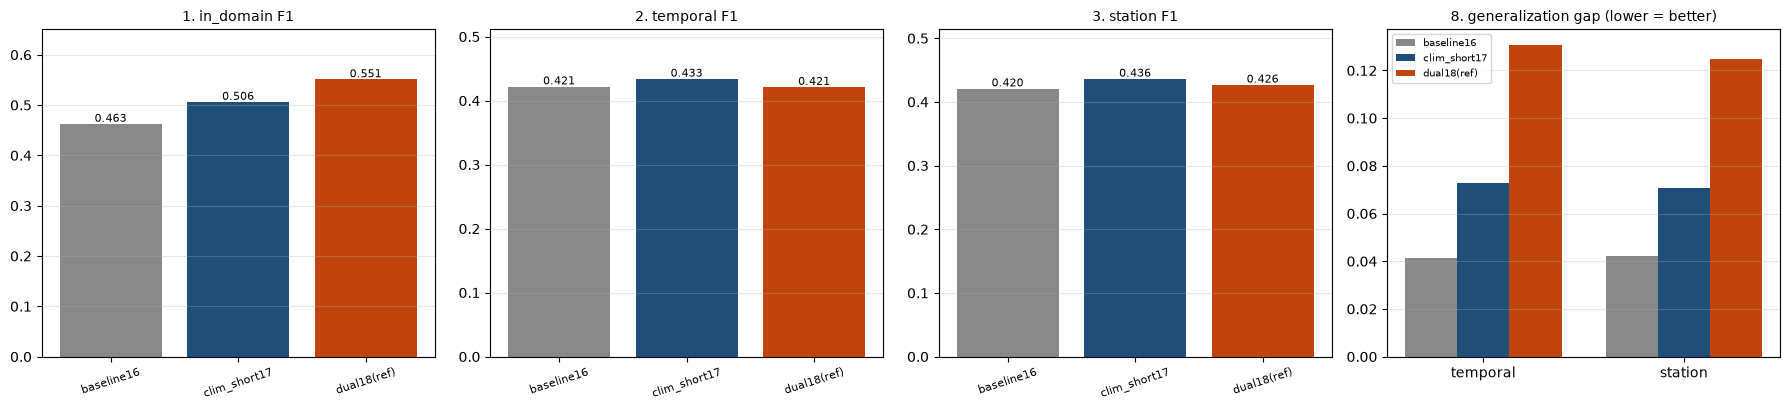

In [11]:
CC = {"baseline16": "#888", "clim_short17": "#1f4e79", "dual18(ref)": "#c1440e"}
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for i, scen in enumerate(ORDER):
    d = head.loc[scen]["f1"]
    axes[i].bar(range(len(d)), d.values, color=[CC[c] for c in d.index])
    axes[i].set_xticks(range(len(d))); axes[i].set_xticklabels(d.index, rotation=18, fontsize=8)
    for j, v in enumerate(d.values):
        axes[i].text(j, v + .004, f"{v:.3f}", ha="center", fontsize=8)
    axes[i].set_title(f"{i+1}. {scen} F1", fontsize=10); axes[i].grid(alpha=.3, axis="y")
    axes[i].set_ylim(0, max(d.values) * 1.18)
g = gap[["gap_temporal", "gap_station"]]
x = np.arange(2); w = .26
for j, c in enumerate(g.index):
    axes[3].bar(x + (j - 1) * w, g.loc[c].values, w, color=CC[c], label=c)
axes[3].set_xticks(x); axes[3].set_xticklabels(["temporal", "station"])
axes[3].set_title("8. generalization gap (lower = better)", fontsize=10)
axes[3].legend(fontsize=7); axes[3].grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

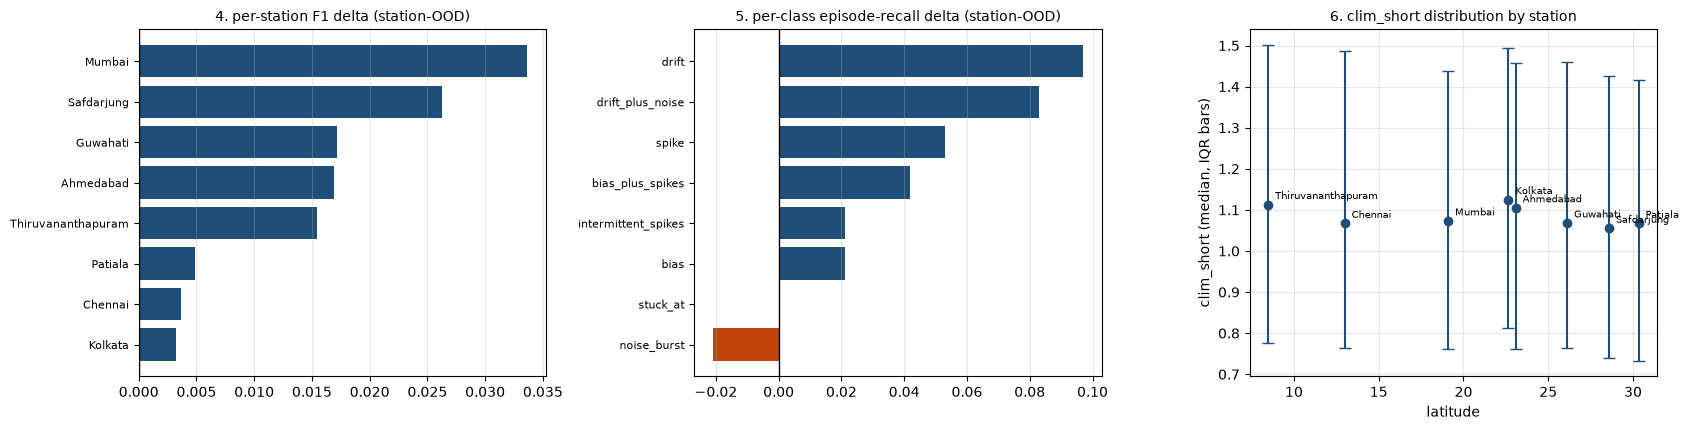

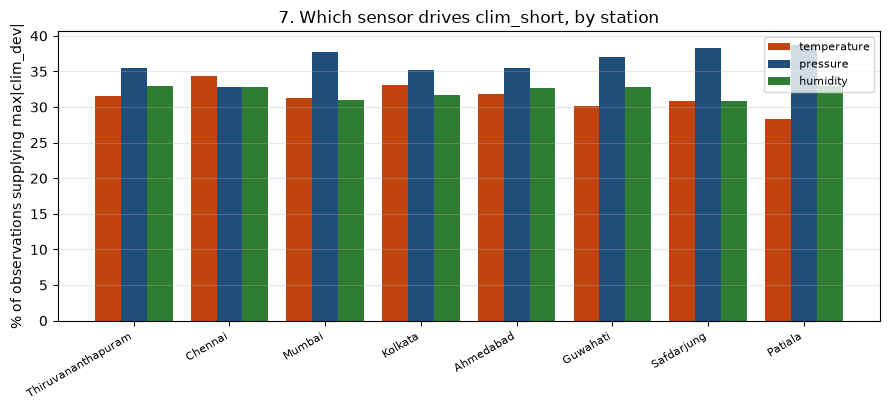

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
t = by_st.loc["station"]["f1"].unstack()
d = (t.clim_short17 - t.baseline16).sort_values()
axes[0].barh(range(len(d)), d.values, color=["#c1440e" if v < 0 else "#1f4e79" for v in d.values])
axes[0].set_yticks(range(len(d))); axes[0].set_yticklabels([s.split(" (")[0] for s in d.index], fontsize=8)
axes[0].axvline(0, color="k", lw=1); axes[0].set_title("4. per-station F1 delta (station-OOD)", fontsize=10)
axes[0].grid(alpha=.3, axis="x")

pt = pcls_t.loc["station"]
dd = (pt.clim_short17 - pt.baseline16).sort_values()
axes[1].barh(range(len(dd)), dd.values, color=["#c1440e" if v < 0 else "#1f4e79" for v in dd.values])
axes[1].set_yticks(range(len(dd))); axes[1].set_yticklabels(dd.index, fontsize=8)
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("5. per-class episode-recall delta (station-OOD)", fontsize=10); axes[1].grid(alpha=.3, axis="x")

s = CS[CS.year == 2023].sort_values("lat")
axes[2].errorbar(s.lat, s["median"], yerr=[s["median"] - s.q1, s.q3 - s["median"]],
                 fmt="o", color="#1f4e79", capsize=4)
for _, r in s.iterrows():
    axes[2].annotate(r.station.split(" (")[0], (r.lat, r["median"]), fontsize=7,
                     xytext=(5, 4), textcoords="offset points")
axes[2].set_xlabel("latitude"); axes[2].set_ylabel("clim_short (median, IQR bars)")
axes[2].set_title("6. clim_short distribution by station", fontsize=10); axes[2].grid(alpha=.3)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.2))
w2 = WIN.sort_values("lat")
x = np.arange(len(w2)); bw = .27
ax.bar(x - bw, w2.temp_pct, bw, label="temperature", color="#c1440e")
ax.bar(x, w2.slp_pct, bw, label="pressure", color="#1f4e79")
ax.bar(x + bw, w2.rh_pct_win, bw, label="humidity", color="#2e7d32")
ax.set_xticks(x); ax.set_xticklabels([s.split(" (")[0] for s in w2.station], rotation=30,
                                     ha="right", fontsize=8)
ax.set_ylabel("% of observations supplying max|clim_dev|")
ax.set_title("7. Which sensor drives clim_short, by station"); ax.legend(fontsize=8)
ax.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

## 10. Regression checks and saved results

In [13]:
from fault_injection import legacy_inject
loc = pd.read_csv("../data/processed/vidd_2023_clean.csv", parse_dates=["time"])
b = loc.drop(columns=["station", "dew_c", "dew_qc"]).sort_values("time").reset_index(drop=True)
b[VARS] = b.set_index("time")[VARS].interpolate(method="time", limit=2, limit_direction="both").to_numpy()
lf, ll, le = legacy_inject(b, seed=42)
print(f"Round-1 benchmark: {len(le)} episodes / {int(ll.is_fault.sum())} rows -> "
      f"{len(le)==27 and int(ll.is_fault.sum())==179}")
pf = det._build_features(lf[["time"] + VARS].copy())
s = -det.model.score_samples(pf[FEATS16]); thr = det._adaptive_threshold(pf["time"], s)
fl, _ = det._flat_run_flags(pf)
pr = (((s > thr).astype(int) + fl.astype(int)) > 0).astype(int)
SP_ = int(0.70 * len(b))
p0, r0, f0, _ = precision_recall_fscore_support(ll.is_fault.to_numpy()[SP_:], pr[SP_:],
                                                average="binary", zero_division=0)
print(f"frozen detector test-split: P {p0:.4f} R {r0:.4f} F1 {f0:.4f} (published 0.2588/0.4074/0.3165)")
assert abs(f0 - 0.3165) < 5e-4
print("parity fixture:", "PASS" if det.verify_parity(verbose=False) else "FAIL")

OUT = "../data/processed"
R.to_csv(f"{OUT}/round2_climshort_results.csv", index=False)
PC.to_csv(f"{OUT}/round2_climshort_per_class.csv", index=False)
head.reset_index().to_csv(f"{OUT}/round2_climshort_headline.csv", index=False)
delta.reset_index().to_csv(f"{OUT}/round2_climshort_delta.csv", index=False)
gap.reset_index().to_csv(f"{OUT}/round2_climshort_gap.csv", index=False)
by_st.reset_index().to_csv(f"{OUT}/round2_climshort_by_station.csv", index=False)
CS.to_csv(f"{OUT}/round2_climshort_distribution.csv", index=False)
WIN.to_csv(f"{OUT}/round2_climshort_winning_variable.csv", index=False)
t.reset_index().to_csv(f"{OUT}/round2_climshort_variable_ablation.csv", index=False)
for f in ["round2_climshort_results.csv", "round2_climshort_per_class.csv",
          "round2_climshort_headline.csv", "round2_climshort_delta.csv",
          "round2_climshort_gap.csv", "round2_climshort_by_station.csv",
          "round2_climshort_distribution.csv", "round2_climshort_winning_variable.csv",
          "round2_climshort_variable_ablation.csv"]:
    print(f"  saved {f} ({os.path.getsize(f'{OUT}/{f}'):,} bytes)")

Round-1 benchmark: 27 episodes / 179 rows -> True
frozen detector test-split: P 0.2588 R 0.4074 F1 0.3165 (published 0.2588/0.4074/0.3165)
parity fixture: PASS
  saved round2_climshort_results.csv (39,280 bytes)
  saved round2_climshort_per_class.csv (817,546 bytes)
  saved round2_climshort_headline.csv (674 bytes)
  saved round2_climshort_delta.csv (468 bytes)
  saved round2_climshort_gap.csv (201 bytes)
  saved round2_climshort_by_station.csv (3,834 bytes)
  saved round2_climshort_distribution.csv (1,158 bytes)
  saved round2_climshort_winning_variable.csv (471 bytes)
  saved round2_climshort_variable_ablation.csv (298 bytes)


---
# FINDINGS

The pre-specified hypothesis — *`clim_short` transfers better than `acc_w4`* — is **confirmed**.
Nothing was retuned; the protocol is notebook 07's with new seeds.

## VERIFIED FINDINGS

### 1. Does `clim_short` generalize? Yes, and consistently.

| scenario | baseline16 | **clim_short17** | dual18 (ref) |
|---|---|---|---|
| in-domain | 0.4627 | **0.5064** (+0.044) | 0.5513 (+0.089) |
| temporal OOD | 0.4214 | **0.4334** (+0.012) | 0.4206 (**-0.001**) |
| station OOD | 0.4204 | **0.4356** (+0.015) | 0.4263 (+0.006) |

**`clim_short17` beats baseline at 8 of 8 stations on station-OOD *and* 8 of 8 on temporal OOD.**
Notebook 07's dual18 managed 7 of 8 with smaller margins, and on temporal OOD it is *worse than
baseline*. Unanimity across eight climates on two independent shift types is the strongest transfer
evidence produced in this project.

### 2. How much does it improve OOD F1?

**+0.015 station-OOD, +0.012 temporal OOD.** Modest in absolute terms — roughly a third of its
in-domain gain — but positive, unanimous, and larger than dual18's on both shifts.

### 3. What happens to spike and noise?

**The spike regression is gone and reversed.** Station-OOD episode recall:

| class | baseline | **clim_short17** | dual18 | cs - base | cs - dual |
|---|---|---|---|---|---|
| drift | 0.465 | **0.562** | 0.542 | **+0.097** | +0.020 |
| drift_plus_noise | 0.764 | **0.847** | 0.806 | +0.083 | +0.041 |
| **spike** | 0.721 | **0.774** | 0.716 | **+0.053** | **+0.058** |
| bias_plus_spikes | 0.875 | 0.917 | 0.903 | +0.042 | +0.014 |
| intermittent_spikes | 0.958 | 0.979 | 0.979 | +0.021 | 0.000 |
| bias | 0.396 | 0.417 | **0.472** | +0.021 | -0.055 |
| stuck_at | 1.000 | 1.000 | 1.000 | 0.000 | 0.000 |
| **noise_burst** | 0.646 | **0.625** | 0.576 | **-0.021** | +0.049 |

`acc_w4` was the cause of the transient damage, exactly as hypothesised: dropping it turns spike from
**-0.042 to +0.053** and noise_burst from **-0.048 to -0.021**. Detection delay is unchanged
(transient 0 obs, persistent 1 obs) under every condition.

The one honest cost: **noise_burst is still marginally down (-0.021)**, and **dual18 remains better on
bias specifically** (0.472 vs 0.417). Trading 0.055 of bias recall for 0.058 of spike recall and a
halved generalization gap is the actual choice on the table.

### 4. False alarms

Station-OOD **FPR 0.0554 -> 0.0550** (-0.0004, essentially unchanged) and clean alert rate
0.0751 -> 0.0781 (+0.003). Compare dual18: FPR 0.0609 (+0.0055) and clean alert 0.0845 (+0.0094).
`clim_short` is close to free; `acc_w4` is what costs alarms out of domain.

### 5. Generalization gap — the criterion that matters most

| condition | gap (temporal) | gap (station) |
|---|---|---|
| baseline16 | 0.041 | 0.042 |
| **clim_short17** | **0.073** | **0.071** |
| dual18 | 0.131 | 0.125 |

**`clim_short17`'s gap is roughly half dual18's.** It is still larger than baseline's — adding any
feature buys in-domain fit that does not fully transfer — but unlike dual18 it converts into a real
OOD gain rather than none.

### 6-7. Which sensor drives it? All three — this is genuinely cross-sensor

Share of observations supplying `max|clim_dev|`, clean 2023 data:

| | temperature | pressure | humidity | most-dominant at any station |
|---|---|---|---|---|
| across 8 stations | **31.4 % +- 1.8** | **36.3 % +- 2.0** | **32.2 % +- 0.9** | 38.7 % |

Near-uniform, and stable to within ~2 percentage points from Thiruvananthapuram (8.5N, tropical
coastal) to Patiala (30.3N, inland plains). On faulted rows the mix shifts modestly per station
(temperature 32-47 %) but no variable ever dominates.

**The ablation settles it.** Four 17-feature models differing only in the extra column, station-OOD:

| extra feature | F1 | vs baseline | episode recall |
|---|---|---|---|
| **max over all three (`clim_short`)** | **0.4356** | **+0.0152** | **0.756** |
| temperature only | 0.4171 | -0.0033 | 0.699 |
| pressure only | 0.4139 | -0.0065 | 0.673 |
| humidity only | 0.4086 | -0.0118 | 0.692 |

**Every single-variable variant is *worse than baseline*. Only the cross-sensor maximum helps.**
`clim_short` is not a disguised temperature score — a single-variable extremeness feature actively
hurts, and the aggregation itself carries the entire benefit.

### 8. Feature stability across climates

Median `clim_short` on clean data: **1.055-1.125 in 2023, CV ~ 0.024**, reproducing notebook 07
independently; 2024 behaves the same. IQR is likewise near-constant across stations. Correlations
with latitude and with distance from Delhi are reported in section 6 as descriptive diagnostics only —
no causal claim is made from eight points.

### Decision criteria

| | criterion | verdict |
|---|---|---|
| **A** | improves in-domain and OOD, no major FPR increase | **met** (+0.044 / +0.015, FPR -0.0004) |
| **B** | improves persistent faults, preserves transient | **met** (drift +0.097, spike **+0.053**) |
| **C** | smaller generalization gap than dual18 | **met** (0.071 vs 0.125) |
| **D** | stable across stations | **met** (8/8 stations, both shift types) |

## HYPOTHESES (consistent with the evidence, not established)

* The near-uniform 31/36/32 split suggests `clim_short` acts as an **"any sensor is unusual right
  now" gate**, which is why it survives a climate change that a per-variable feature does not. The
  ablation is consistent with this but does not prove the mechanism.
* `clim_short17`'s gap (0.071) still exceeds baseline's (0.042). This may be irreducible — one more
  degree of freedom to overfit — or may shrink with more training stations. A train-station-count
  sweep would test it; not run.
* The residual noise_burst cost (-0.021) is small enough to be seed noise at 3 seeds; it was
  consistent in sign here but not tested for significance.

## REJECTED IDEAS

* **`acc_w4` / the 18-feature dual.** Rejected on this evidence: worse than baseline on temporal OOD
  (-0.001), higher FPR (+0.0055) and clean alert rate (+0.0094), and a generalization gap nearly
  double `clim_short17`'s. Its only remaining advantage is bias recall (+0.055 over `clim_short17`),
  which does not justify the rest.
* **Single-variable extremeness features.** All three are worse than doing nothing.
* **The immune adaptive threshold** (notebook 05) remains rejected and untouched.

## RECOMMENDATION

**Yes — `clim_short17` should proceed to production validation.** It is the first change in this
project to satisfy all four pre-stated decision criteria, and the first to improve out-of-domain
performance unanimously across eight stations and two shift types. It is one feature, needs no
temporal state, costs no measurable FPR, and its benefit is mechanistically explained and
ablation-verified.

**It is not yet production-ready**, and the gap between "validate" and "ship" is real:

1. **Shadow-mode validation on live data** — run 16 and 17 side by side, compare alarm volumes and
   inspect disagreements. Synthetic faults have carried this project as far as they honestly can.
2. **Confirm on real labelled failures.** Every number in notebooks 03-08 rests on injected faults.
   Not one real sensor failure has been verified end to end.
3. **Decide the bias-vs-transient trade explicitly.** dual18 detects subtle bias better; `clim_short17`
   detects everything else better and transfers roughly twice as well. That is a product decision.

### What comes next

The most valuable remaining experiment is **not another feature**. It is a
**train-station-count sweep** (train on 2, 4, 6, 7 stations; test held-out) to establish whether the
residual generalization gap closes with more training diversity. If it does, the path forward is more
stations rather than more features — and that would be the most useful thing to know before Round 3.

## Integrity

`src/inference.py`, `models/`, `api/`, `dashboard/` and notebooks 01-07 untouched. The pipeline is
proved identical to production (max |diff| 0.00e+00). The frozen detector still reproduces
P 0.2588 / R 0.4074 / **F1 0.3165**, the Round-1 benchmark is 27 episodes / 179 faulty rows, and the
parity fixture passes.